In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import plotly.express as px
from wordcloud import WordCloud

In [24]:
# Load Data
data_path = Path("../data/raw/customer_support_tickets.csv")
print(data_path)
df = pd.read_csv(data_path)

..\data\raw\customer_support_tickets.csv


In [25]:
df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [26]:
# Basic overview
df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   object 
 2   Customer Email                8469 non-null   object 
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   object 
 5   Product Purchased             8469 non-null   object 
 6   Date of Purchase              8469 non-null   object 
 7   Ticket Type                   8469 non-null   object 
 8   Ticket Subject                8469 non-null   object 
 9   Ticket Description            8469 non-null   object 
 10  Ticket Status                 8469 non-null   object 
 11  Resolution                    2769 non-null   object 
 12  Ticket Priority               8469 non-null   object 
 13  Tic

In [28]:
df.describe(include='all')

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
count,8469.000000,8469,8469,8469.000000,8469,8469,8469,8469,8469,8469,8469,2769,8469,8469,5650,2769,2769.000000
unique,NaN,8028,8320,NaN,3,42,730,5,16,8077,3,2769,4,4,5470,2728,NaN
top,NaN,Michael Garcia,asmith@example.com,NaN,Male,Canon EOS,2020-10-21,Refund request,Refund request,I'm having an issue with the {product_purchase...,Pending Customer Response,Case maybe show recently my computer follow.,Medium,Email,2023-06-01 20:45:39,2023-06-01 17:14:42,NaN
freq,NaN,5,4,NaN,2896,240,24,1752,576,25,2881,1,2192,2143,3,3,NaN
mean,4235.000000,NaN,NaN,44.026804,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.991333
std,2444.934048,NaN,NaN,15.296112,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.407016
min,1.000000,NaN,NaN,18.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000
25%,2118.000000,NaN,NaN,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000
50%,4235.000000,NaN,NaN,44.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.000000
75%,6352.000000,NaN,NaN,57.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.000000


In [29]:
# Missing Values
missing = df.isnull().sum()

missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing,
    'Percentage': missing_percent
})

missing_df.sort_values(by='Percentage', ascending=False)

,Missing Values,Percentage
Customer Satisfaction Rating,5700,67.304286
Resolution,5700,67.304286
Time to Resolution,5700,67.304286
First Response Time,2819,33.286102
Ticket ID,0,0.000000
Customer Name,0,0.000000
Customer Email,0,0.000000
Customer Age,0,0.000000
Customer Gender,0,0.000000
Ticket Subject,0,0.000000


In [30]:
# Analyze null values
df[
    (df['Ticket Status'] == 'Closed') &
    (
        df['Resolution'].isnull() |
        df['Time to Resolution'].isnull() |
        df['Customer Satisfaction Rating'].isnull()
    )
]

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating


In [31]:
# Empty Dataframe confirms that null values only exist in unresolved tickets
# and are a part of business-process.

In [32]:
# Categorical distribution
categorical_cols = ['Ticket Type', 'Ticket Priority', 'Ticket Channel', 'Customer Satisfaction Rating', 'Ticket Status']


In [33]:
for col in categorical_cols:
    fig = px.histogram(df, x=col, title=f"{col} Distribution")
    fig.show()

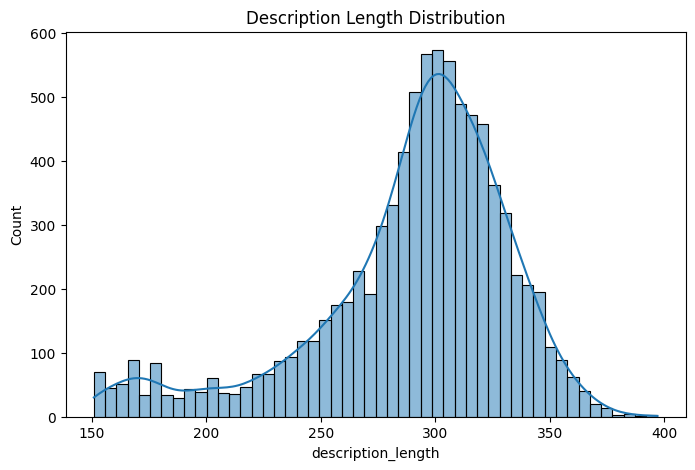

In [34]:
# Create text length column
df['description_length'] = df['Ticket Description'].astype(str).apply(len)

# Histogram
plt.figure(figsize=(8,5))
sns.histplot(df['description_length'], bins=50, kde=True)
plt.title("Description Length Distribution")
plt.show()

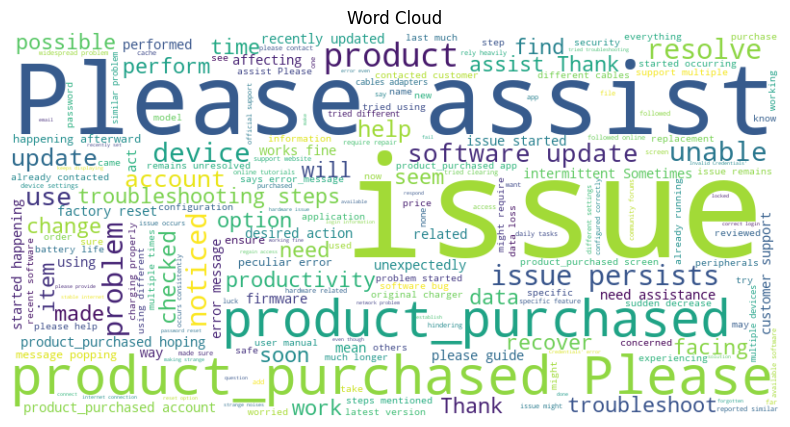

In [35]:
text = " ".join(df['Ticket Description'].dropna().astype(str))

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud")
plt.show()

In [36]:
for col in categorical_cols:
    print(f"\n{col} Value Counts:")
    print(df[col].value_counts(normalize=True) * 100)


Ticket Type Value Counts:
Ticket Type
Refund request          20.687212
Technical issue         20.628173
Cancellation request    20.014169
Product inquiry         19.376550
Billing inquiry         19.293895
Name: proportion, dtype: float64

Ticket Priority Value Counts:
Ticket Priority
Medium      25.882631
Critical    25.138741
High        24.619199
Low         24.359429
Name: proportion, dtype: float64

Ticket Channel Value Counts:
Ticket Channel
Email           25.304050
Phone           25.174165
Social media    25.044279
Chat            24.477506
Name: proportion, dtype: float64

Customer Satisfaction Rating Value Counts:
Customer Satisfaction Rating
3.0    20.946190
1.0    19.971109
2.0    19.826652
5.0    19.646082
4.0    19.609967
Name: proportion, dtype: float64

Ticket Status Value Counts:
Ticket Status
Pending Customer Response    34.018184
Open                         33.286102
Closed                       32.695714
Name: proportion, dtype: float64


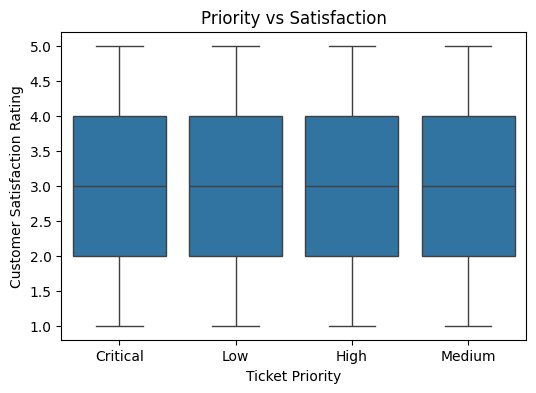

In [37]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='Ticket Priority', y='Customer Satisfaction Rating')
plt.title("Priority vs Satisfaction")
plt.show()

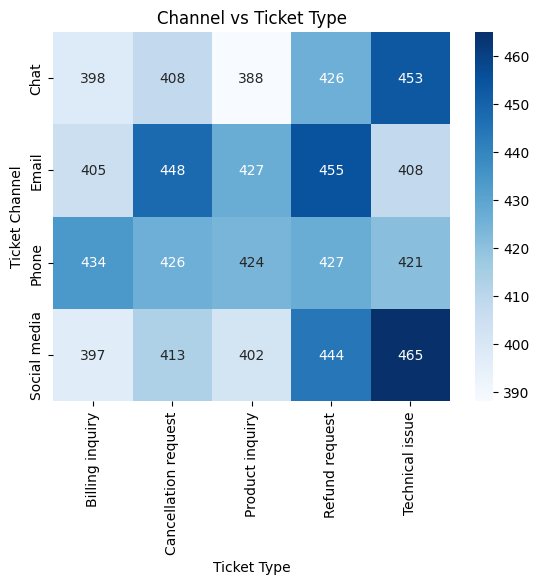

In [38]:
cross_tab = pd.crosstab(df['Ticket Channel'], df['Ticket Type'])

sns.heatmap(cross_tab, annot=True, fmt='d', cmap='Blues')
plt.title("Channel vs Ticket Type")
plt.show()

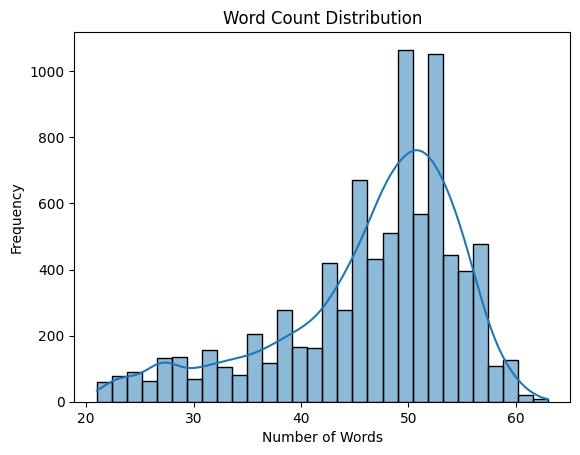

In [39]:
df['word_count'] = (
    df['Ticket Description']
    .astype(str)
    .apply(lambda x: len(x.split()))
)

sns.histplot(df['word_count'], bins=30, kde=True)

plt.title("Word Count Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

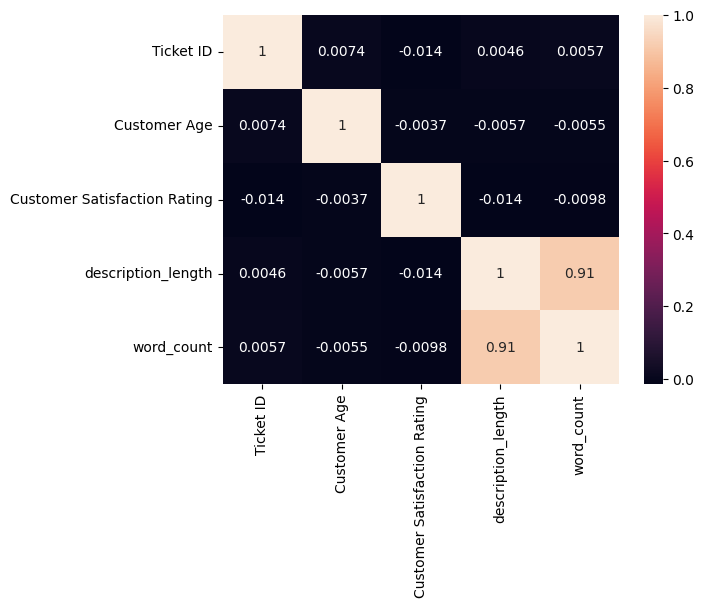

In [40]:
numeric_df = df.select_dtypes(include='number')

sns.heatmap(numeric_df.corr(), annot=True)
plt.show()

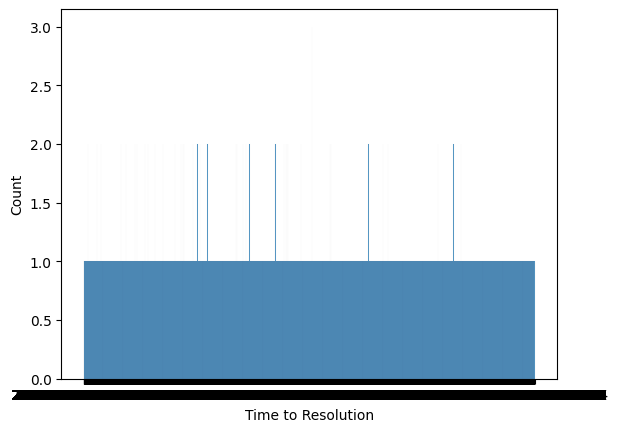

In [41]:
# Resolved ticket analysis
resolved_df = df[df['Time to Resolution'].notnull()]

sns.histplot(resolved_df['Time to Resolution'])
plt.show()

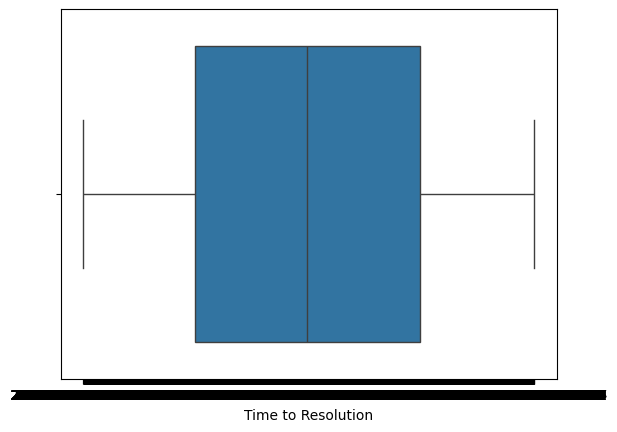

In [42]:
# Resolution time
sns.boxplot(x=resolved_df['Time to Resolution'])
plt.show()

<Axes: xlabel='Ticket Priority', ylabel='Time to Resolution'>

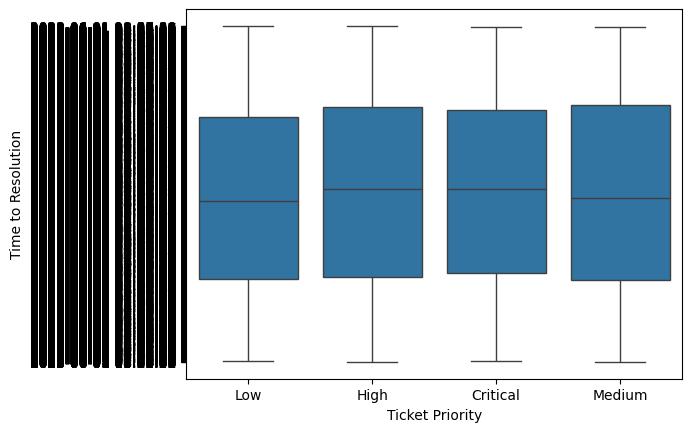

In [43]:
sns.boxplot(
    data=resolved_df,
    x='Ticket Priority',
    y='Time to Resolution'
)

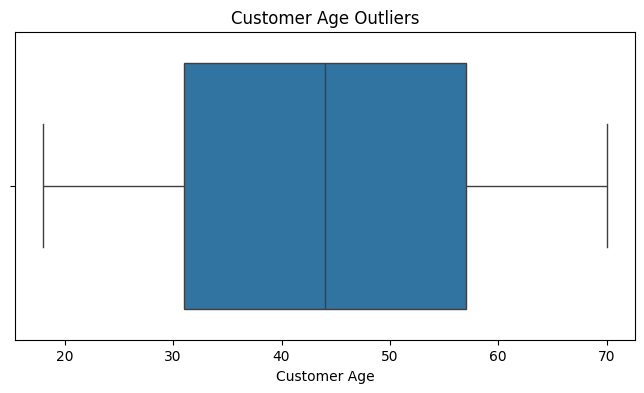

In [44]:
# Analysing outliers
plt.figure(figsize=(8,4))

sns.boxplot(x=df['Customer Age'])

plt.title("Customer Age Outliers")

plt.show()

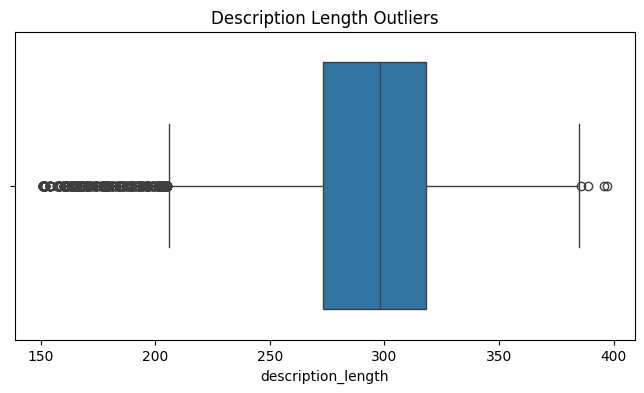

In [45]:
plt.figure(figsize=(8,4))

sns.boxplot(x=df['description_length'])

plt.title("Description Length Outliers")

plt.show()

In [46]:
resolved_df = df[df['Time to Resolution'].notnull()]

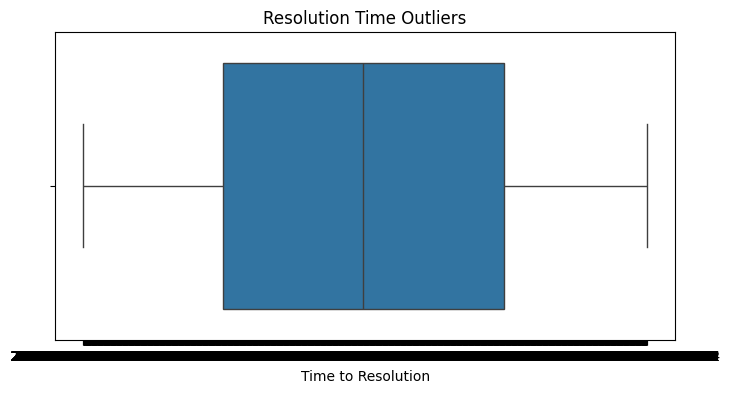

In [47]:
plt.figure(figsize=(8,4))

sns.boxplot(x=resolved_df['Time to Resolution'])

plt.title("Resolution Time Outliers")

plt.show()

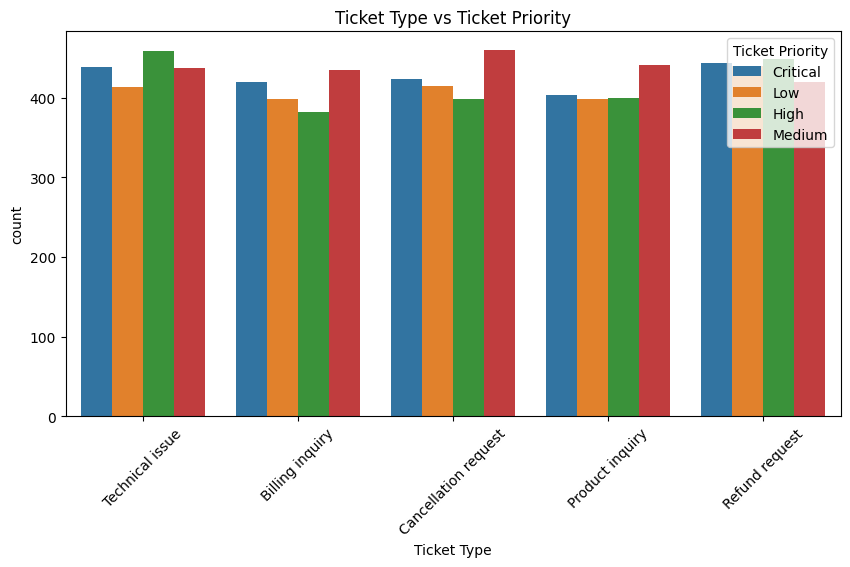

In [48]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='Ticket Type',
    hue='Ticket Priority'
)

plt.xticks(rotation=45)

plt.title("Ticket Type vs Ticket Priority")

plt.show()

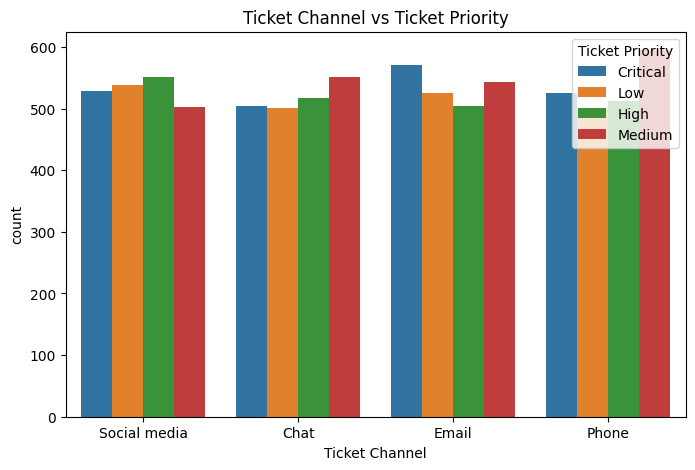

In [49]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Ticket Channel',
    hue='Ticket Priority'
)

plt.title("Ticket Channel vs Ticket Priority")

plt.show()

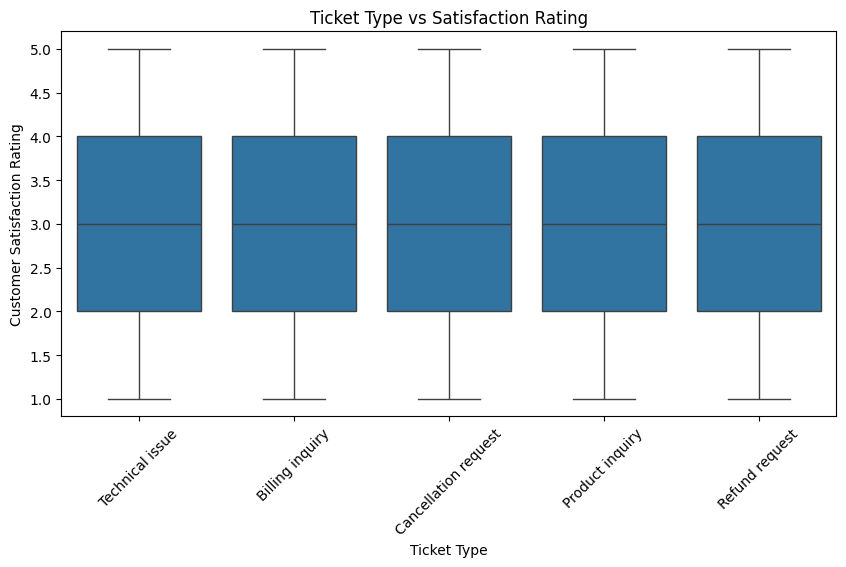

In [50]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=resolved_df,
    x='Ticket Type',
    y='Customer Satisfaction Rating'
)

plt.xticks(rotation=45)

plt.title("Ticket Type vs Satisfaction Rating")

plt.show()

Apply basic feature engineering

In [51]:
df =pd.read_csv(data_path)

In [52]:
# create new features

df['description_length'] = (
    df['Ticket Description']
    .astype(str)
    .apply(len)
)

df['word_count'] = (
    df['Ticket Description']
    .astype(str)
    .apply(lambda x: len(x.split()))
)

df['avg_word_length'] = (
    df['Ticket Description']
    .astype(str)
    .apply(
        lambda x: sum(len(word) for word in x.split()) /
        (len(x.split()) + 1)
    )
)

import re

df['special_char_count'] = (
    df['Ticket Description']
    .astype(str)
    .apply(
        lambda x: len(re.findall(r'[^a-zA-Z0-9\s]', x))
    )
)

df['uppercase_count'] = (
    df['Ticket Description']
    .astype(str)
    .apply(
        lambda x: sum(1 for c in x if c.isupper())
    )
)

In [53]:
# preview
df[[
    'description_length',
    'word_count',
    'avg_word_length',
    'special_char_count',
    'uppercase_count'
]].head()

,description_length,word_count,avg_word_length,special_char_count,uppercase_count
0,284,43,5.431818,13,6
1,282,44,5.244444,17,9
2,275,42,5.418605,21,5
3,262,41,5.261905,13,6
4,333,55,4.946429,14,7


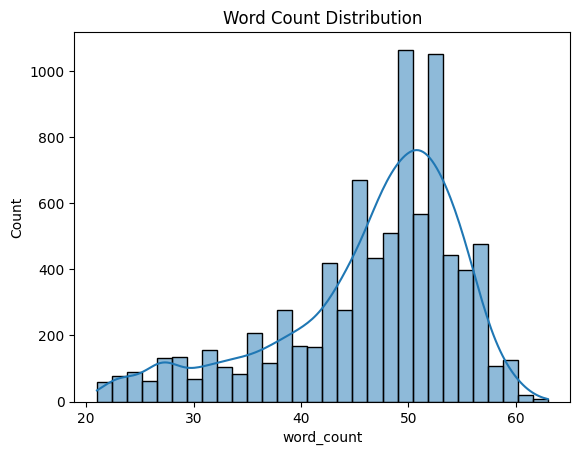

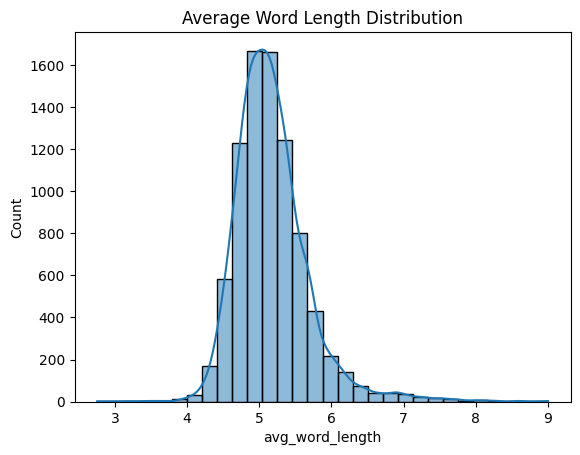

In [55]:
# visualize engineered features
sns.histplot(df['word_count'], bins=30, kde=True)

plt.title("Word Count Distribution")

plt.show()

sns.histplot(df['avg_word_length'], bins=30, kde=True)

plt.title("Average Word Length Distribution")

plt.show()

In [54]:
df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,...,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating,description_length,word_count,avg_word_length,special_char_count,uppercase_count
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,...,Critical,Social media,2023-06-01 12:15:36,NaN,NaN,284,43,5.431818,13,6
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,...,Critical,Chat,2023-06-01 16:45:38,NaN,NaN,282,44,5.244444,17,9
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,...,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0,275,42,5.418605,21,5
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,...,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0,262,41,5.261905,13,6
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,...,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0,333,55,4.946429,14,7
